In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [49]:
df_train = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
df_test  = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (175341, 45)
Test shape : (82332, 45)


In [50]:
drop_cols = ['id', 'attack_cat']

df_train = df_train.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)

In [51]:
df_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,1,0,0,0,1,1,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,1,2,0,0,0,1,6,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,1,3,0,0,0,2,6,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,1,3,1,1,0,2,1,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,2,1,40,0,0,0,2,39,0,0


In [52]:
print(df_train["label"].unique())

[0 1]



Correlation Matrix:

                        dur     spkts     dpkts    sbytes    dbytes      rate  \
dur                1.000000  0.254559  0.181182  0.199731  0.144134 -0.120966   
spkts              0.254559  1.000000  0.390067  0.963791  0.206609 -0.076358   
dpkts              0.181182  0.390067  1.000000  0.188476  0.971907 -0.098202   
sbytes             0.199731  0.963791  0.188476  1.000000  0.009926 -0.028468   
dbytes             0.144134  0.206609  0.971907  0.009926  1.000000 -0.059475   
rate              -0.120966 -0.076358 -0.098202 -0.028468 -0.059475  1.000000   
sttl               0.012196 -0.102723 -0.192580 -0.020860 -0.135515  0.407572   
dttl               0.044159  0.068246  0.053861  0.063009  0.023559 -0.414546   
sload             -0.081749 -0.051646 -0.066710 -0.018322 -0.040430  0.602492   
dload             -0.050603  0.075897  0.139145 -0.007829  0.104757 -0.153051   
sloss              0.198597  0.971069  0.204883  0.996109  0.017366 -0.042923   
dloss 

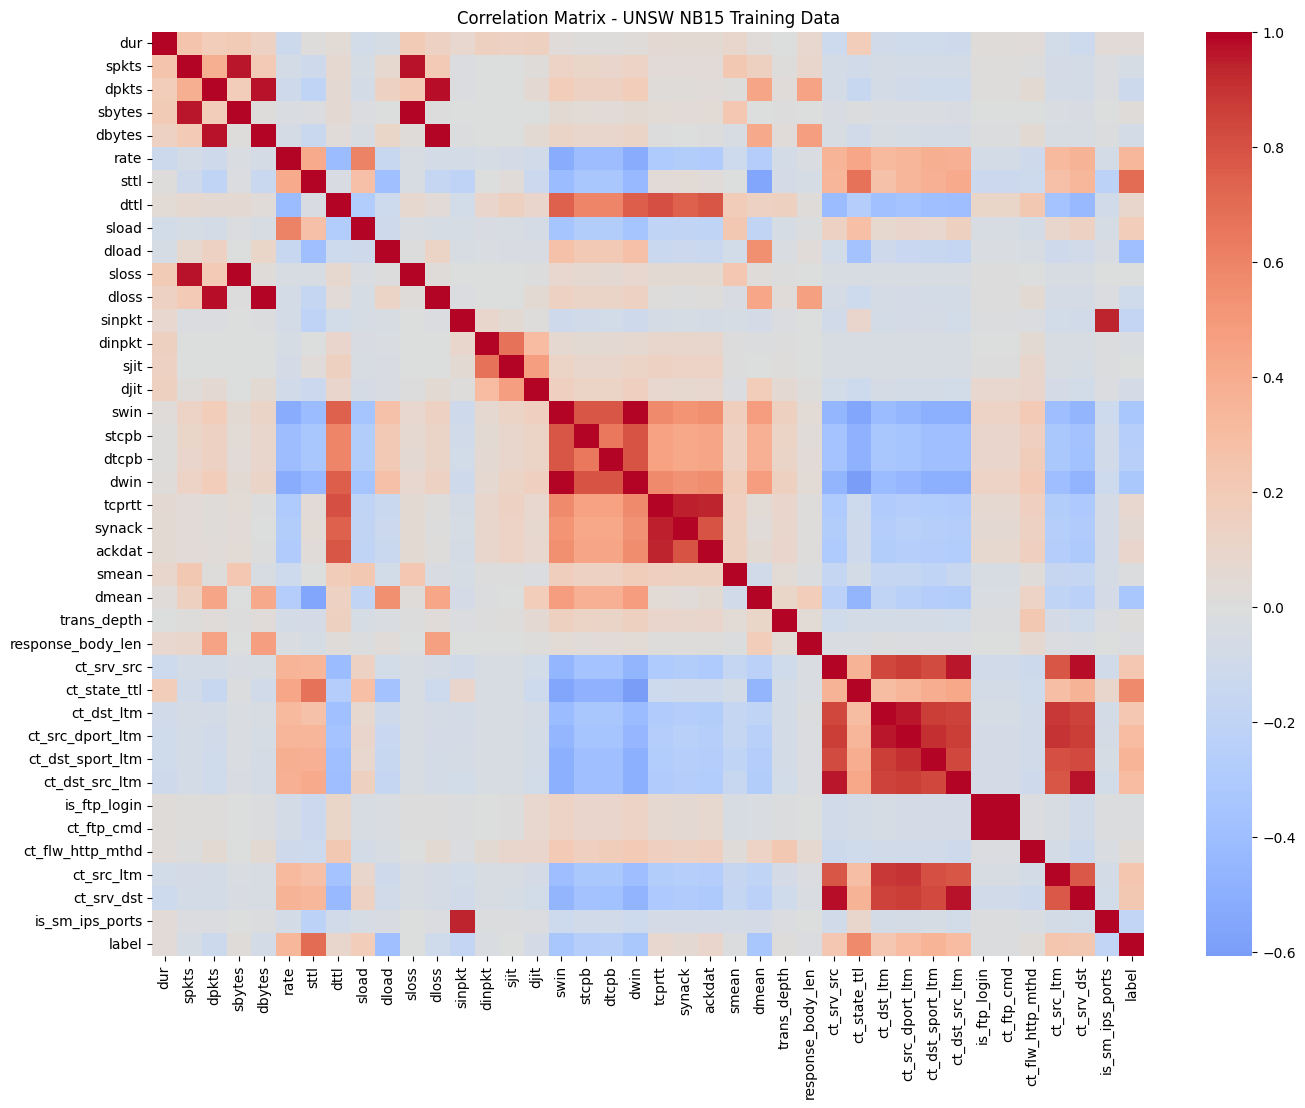

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Select only numeric columns
numeric_df = df_train.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Print correlation matrix
print("\nCorrelation Matrix:\n")
print(corr_matrix)

# Correlation with label
print("\nCorrelation with label:\n")
print(corr_matrix["label"].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix - UNSW NB15 Training Data")
plt.show()

In [54]:
# Correlation of all features with label
label_corr = corr_matrix["label"].drop("label")

# Sort correlations
label_corr_sorted = label_corr.abs().sort_values(ascending=False)

print("\nTop features correlated with label:\n")
print(label_corr_sorted.head(15))


Top features correlated with label:

sttl                0.692741
ct_state_ttl        0.577704
dload               0.393739
ct_dst_sport_ltm    0.357213
dmean               0.341806
rate                0.337979
swin                0.333633
dwin                0.319626
ct_src_dport_ltm    0.305579
ct_dst_src_ltm      0.303855
stcpb               0.255006
dtcpb               0.250340
ct_src_ltm          0.238225
ct_dst_ltm          0.229887
ct_srv_src          0.229044
Name: label, dtype: float64


Class Distribution:
label
1    119341
0     56000
Name: count, dtype: int64


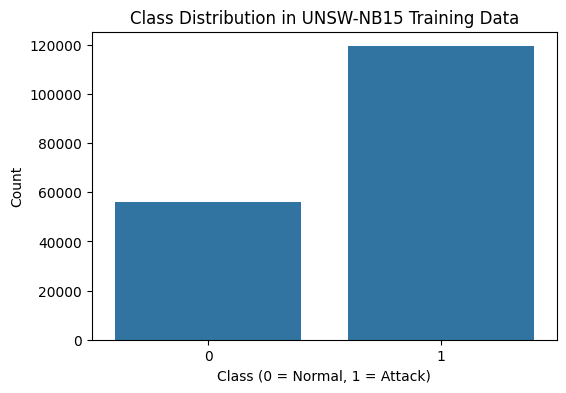

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class distribution
class_counts = df_train['label'].value_counts()

print("Class Distribution:")
print(class_counts)

# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_train)
plt.title("Class Distribution in UNSW-NB15 Training Data")
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()

In [21]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test  = df_test.drop(columns=['label'])
y_test  = df_test['label']

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=50
        ), cat_features)
    ]
)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

feature_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"   # keeps top 50% important features
)

In [24]:
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [25]:
from sklearn.pipeline import Pipeline

pipeline_fs = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', final_rf)
])

In [26]:
start_time = time.time()
pipeline_fs.fit(X_train, y_train)
training_time = time.time() - start_time

print("Training Time (s):", round(training_time, 2))

Training Time (s): 134.8


In [27]:
y_prob = pipeline_fs.predict_proba(X_test)[:, 1]

THRESHOLD = 0.4
y_pred = (y_prob > THRESHOLD).astype(int)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8853179808579896
Precision: 0.835433100302815
Recall   : 0.985926056648725
F1 Score : 0.9044622078316301
ROC-AUC  : 0.9851318136940435


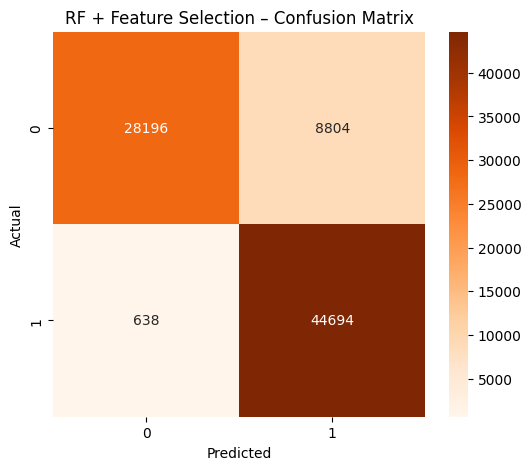

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RF + Feature Selection – Confusion Matrix")
plt.show()

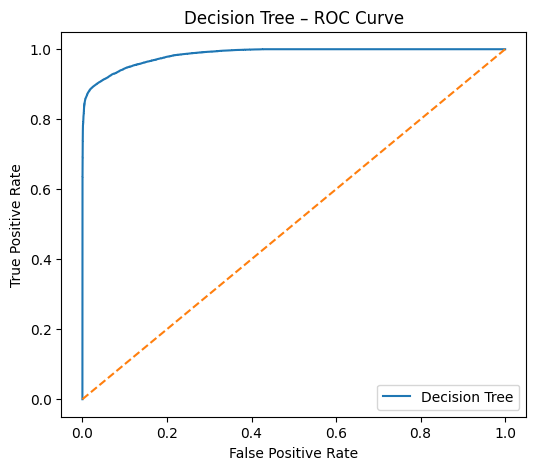

0.6158512926466856
0.6158383905843859
0.6157451021510909
0.615718797378393
0.6155976312275991
0.6153932097991068
0.6153365583848398
0.6152804869862376
0.6152441867437758
0.6151899948307601
0.6151734808487277
0.6151545858820044
0.615129567486828
0.6151178038355024
0.6150221790438656
0.6149986870554791
0.6149843688430616
0.6149324216260711
0.614868668145375
0.6148598255732337
0.6147923729549631
0.6147393318407892
0.6147265460463646
0.6146563599010991
0.6146405514894333
0.6146376967142568
0.6146164461306756
0.6145292771653983
0.6145128636692246
0.6144855872965984
0.6144787396736746
0.6143322827999647
0.6141708719089094
0.6141170672330538
0.6141159550621451
0.6138526411244378
0.6135281057818067
0.6133459784117584
0.6133322174742557
0.6132779414025579
0.6132748755380452
0.6131272338792637
0.6130398380486908
0.6129595190797901
0.6129560703426622
0.6128843725356297
0.6128561502990711
0.6127688438574868
0.6127179243268237
0.6126701994567139
0.6126680097056351
0.6126462165314621
0.6126254714033

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree – ROC Curve")
plt.legend()
plt.show()
for i in range(len(thresholds)):
    if tpr[i] >=.95 and fpr[i]<=.25:
        print(thresholds[i])

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

y_train_pred = pipeline_fs.predict(X_train)
y_train_prob = pipeline_fs.predict_proba(X_train)[:, 1]

y_test_pred = pipeline_fs.predict(X_test)
y_test_prob = pipeline_fs.predict_proba(X_test)[:, 1]

results_rf = {
    "Model": "Random Forest",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred),
    "Train Recall": recall_score(y_train, y_train_pred),
    "Train F1": f1_score(y_train, y_train_pred),
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred),
    "Test Recall": recall_score(y_test, y_test_pred),
    "Test F1": f1_score(y_test, y_test_pred),
    "Test ROC-AUC": roc_auc_score(y_test, y_test_prob)
}

results_rf

{'Model': 'Random Forest',
 'Train Accuracy': 0.9630833632749899,
 'Train Precision': 0.9848615025087635,
 'Train Recall': 0.9605248824796172,
 'Train F1': 0.9725409679595135,
 'Train ROC-AUC': 0.9966470752477594,
 'Test Accuracy': 0.9048486615167857,
 'Test Precision': 0.8708267405063291,
 'Test Recall': 0.9712565075443396,
 'Test F1': 0.9183039252492388,
 'Test ROC-AUC': 0.9851318136940435}

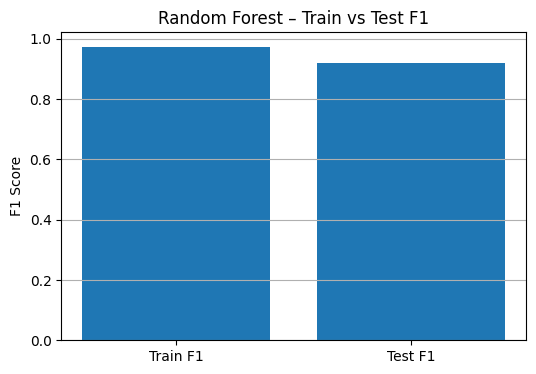

In [32]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Train F1', 'Test F1'],
    [results_rf['Train F1'], results_rf['Test F1']]
)

plt.ylabel("F1 Score")
plt.title("Random Forest – Train vs Test F1")
plt.grid(axis='y')
plt.show()

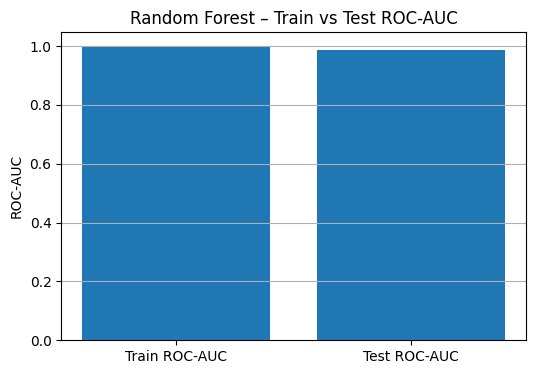

In [33]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Train ROC-AUC', 'Test ROC-AUC'],
    [results_rf['Train ROC-AUC'], results_rf['Test ROC-AUC']]
)

plt.ylabel("ROC-AUC")
plt.title("Random Forest – Train vs Test ROC-AUC")
plt.grid(axis='y')
plt.show()

In [34]:
import joblib

joblib.dump(pipeline_fs, "rf_ids_model_with_feature_selection.joblib")
print("Model with feature selection saved")

Model with feature selection saved
